In [6]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import missingno as msno
import category_encoders as ce

# Step 1: Ingestion from external source
url = 'https://raw.githubusercontent.com/xingtianma/econ3916/refs/heads/main/data/messy_hr_economics.csv'
df = pd.read_csv(url)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3200 entries, 0 to 3199
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   employee_id             3200 non-null   object 
 1   department_raw          3200 non-null   object 
 2   department              3200 non-null   object 
 3   office_zip              3200 non-null   int64  
 4   tenure_years            3200 non-null   float64
 5   age                     3200 non-null   int64  
 6   year_hired              3200 non-null   int64  
 7   regional_unemployment   3200 non-null   float64
 8   regional_cpi_inflation  3200 non-null   float64
 9   performance_rating      2748 non-null   float64
 10  bonus_pay               2748 non-null   float64
 11  base_salary             2849 non-null   float64
 12  retention_risk          3200 non-null   float64
dtypes: float64(7), int64(3), object(3)
memory usage: 325.1+ KB


<Axes: >

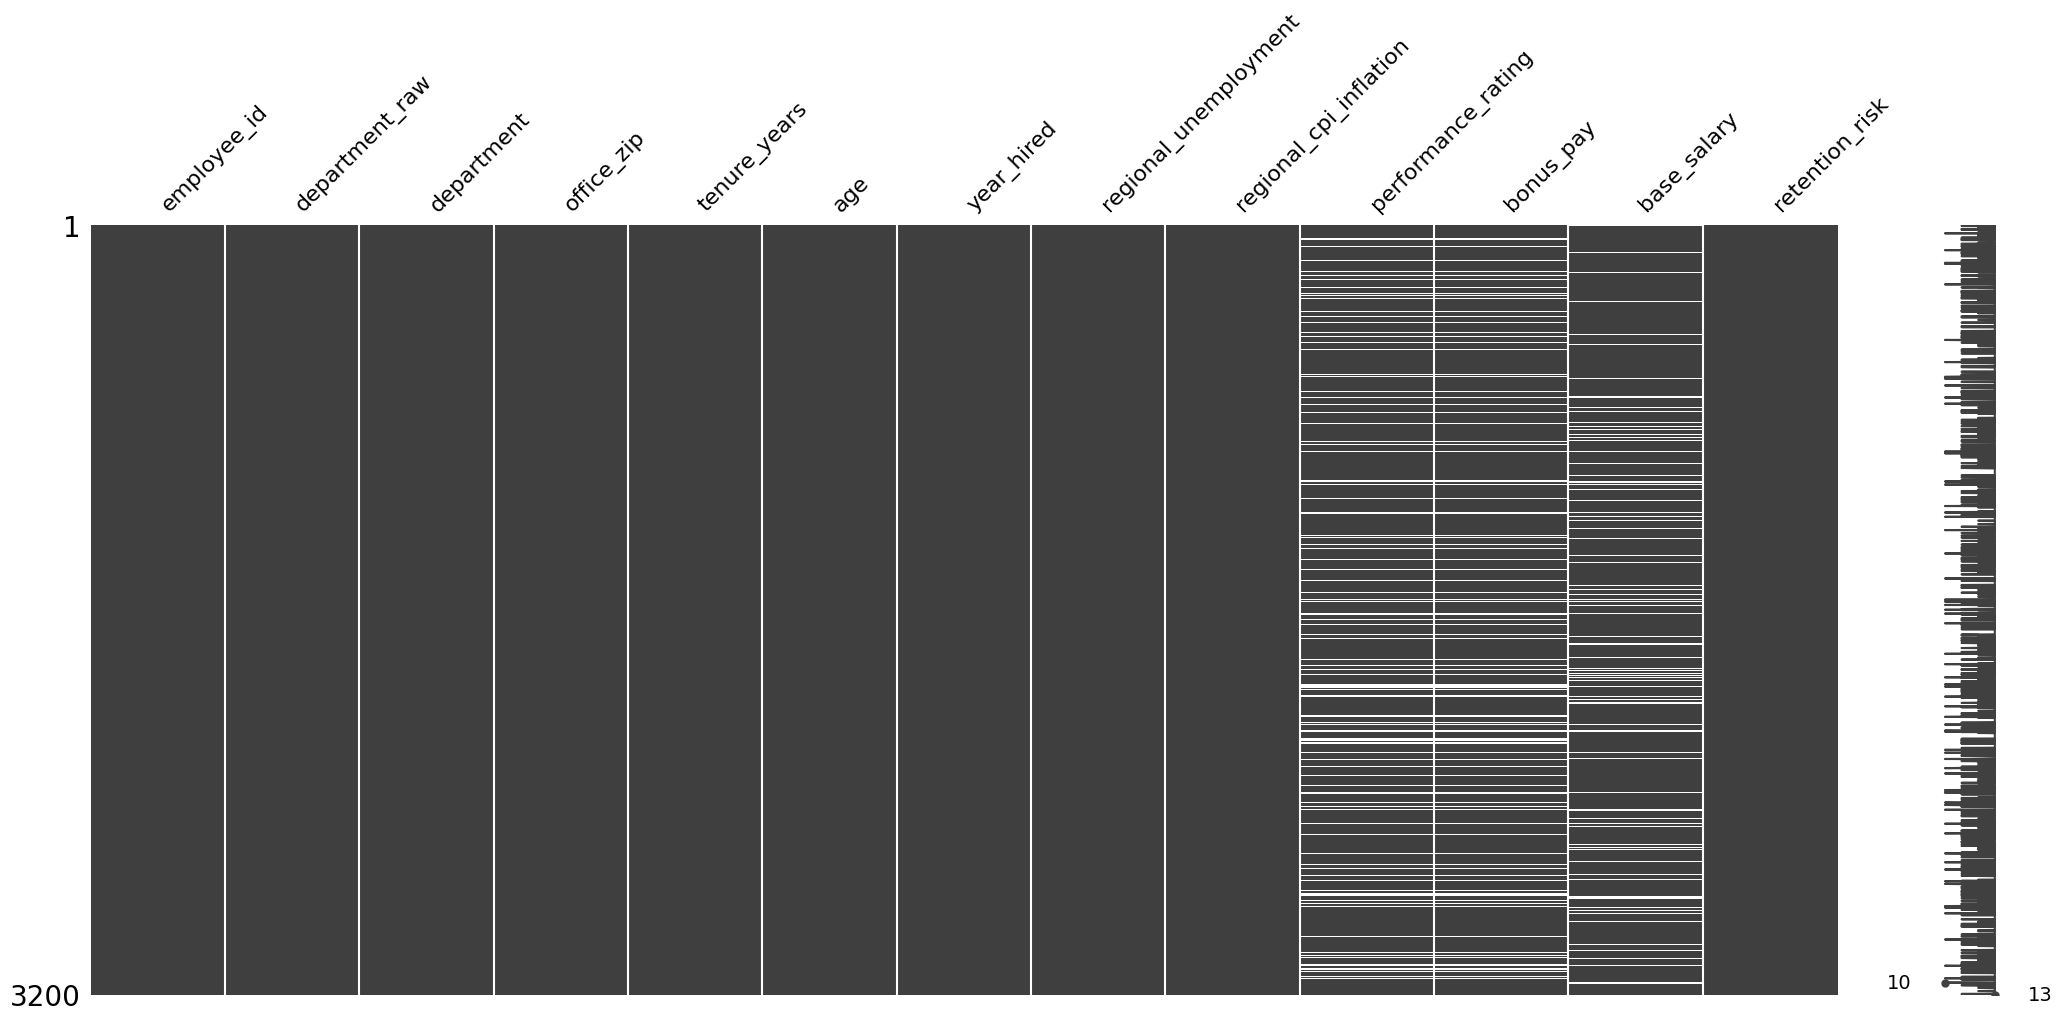

In [7]:
msno.matrix(df)

In [8]:
# Step 3: Grouped Conditional Imputation
# Imputing the median salary based on department to preserve variance structures
df['base_salary'] = df.groupby('department')['base_salary'].transform(lambda x: x.fillna(x.median()))

In [9]:
# Step 4: The Dummy Variable Trap (Intentional Failure)
dummies_trap = pd.get_dummies(df['department'], prefix='dept').astype(int)
X_trap = pd.concat([df[['tenure_years']], dummies_trap], axis=1)

# Adding the constant intercept creates perfect multicollinearity
X_trap = sm.add_constant(X_trap)
y = df['base_salary']

# This will trigger a severe multicollinearity warning or a LinAlgError
model_trap = sm.OLS(y, X_trap).fit()
print(model_trap.summary())

                            OLS Regression Results                            
Dep. Variable:            base_salary   R-squared:                       0.744
Model:                            OLS   Adj. R-squared:                  0.743
Method:                 Least Squares   F-statistic:                     3090.
Date:                Wed, 11 Mar 2026   Prob (F-statistic):               0.00
Time:                        15:52:50   Log-Likelihood:                -34010.
No. Observations:                3200   AIC:                         6.803e+04
Df Residuals:                    3196   BIC:                         6.805e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const             5.765e+04    244.020  

In [10]:
# Step 5: Escaping the Trap (k-1 methodology)
# drop_first=True establishes the reference category
dummies_safe = pd.get_dummies(df['department'], prefix='dept', drop_first=True).astype(int)
X_safe = pd.concat([df[['tenure_years']], dummies_safe], axis=1)
X_safe = sm.add_constant(X_safe)
model_safe = sm.OLS(y, X_safe).fit()
print(model_safe.summary())

# Step 5b: Target Encoding High Cardinality
# Condensing 800 ZIP codes into a single continuous vector representing average salary
encoder = ce.TargetEncoder(cols="office_zip")
df['zip_encoded'] = encoder.fit_transform(df['office_zip'], df['base_salary'])

                            OLS Regression Results                            
Dep. Variable:            base_salary   R-squared:                       0.744
Model:                            OLS   Adj. R-squared:                  0.743
Method:                 Least Squares   F-statistic:                     3090.
Date:                Wed, 11 Mar 2026   Prob (F-statistic):               0.00
Time:                        15:56:15   Log-Likelihood:                -34010.
No. Observations:                3200   AIC:                         6.803e+04
Df Residuals:                    3196   BIC:                         6.805e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const           9.527e+04    372.412    255.